<a href="https://colab.research.google.com/github/RuiYan2022/Clinical_Trial/blob/main/Python_Lesson7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

!wget https://raw.githubusercontent.com/RuiYan2022/Clinical_Trial/refs/heads/main/clinical_trial_generated.csv

--2026-02-26 23:38:20--  https://raw.githubusercontent.com/RuiYan2022/Clinical_Trial/refs/heads/main/clinical_trial_generated.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 24442 (24K) [text/plain]
Saving to: ‘clinical_trial_generated.csv’

clinical_trial_gene 100%[===================>]  23.87K  --.-KB/s    in 0s      

2026-02-26 23:38:20 (108 MB/s) - ‘clinical_trial_generated.csv’ saved [24442/24442]



In [38]:


df = pd.read_csv("clinical_trial_generated.csv")

In [36]:
df.columns

Index(['patient_id', 'treatment_group', 'age', 'gender', 'dose',
       'baseline_score', 'week4_score', 'week8_score', 'biomarker_level',
       'adverse_event', 'improvement_score'],
      dtype='object')

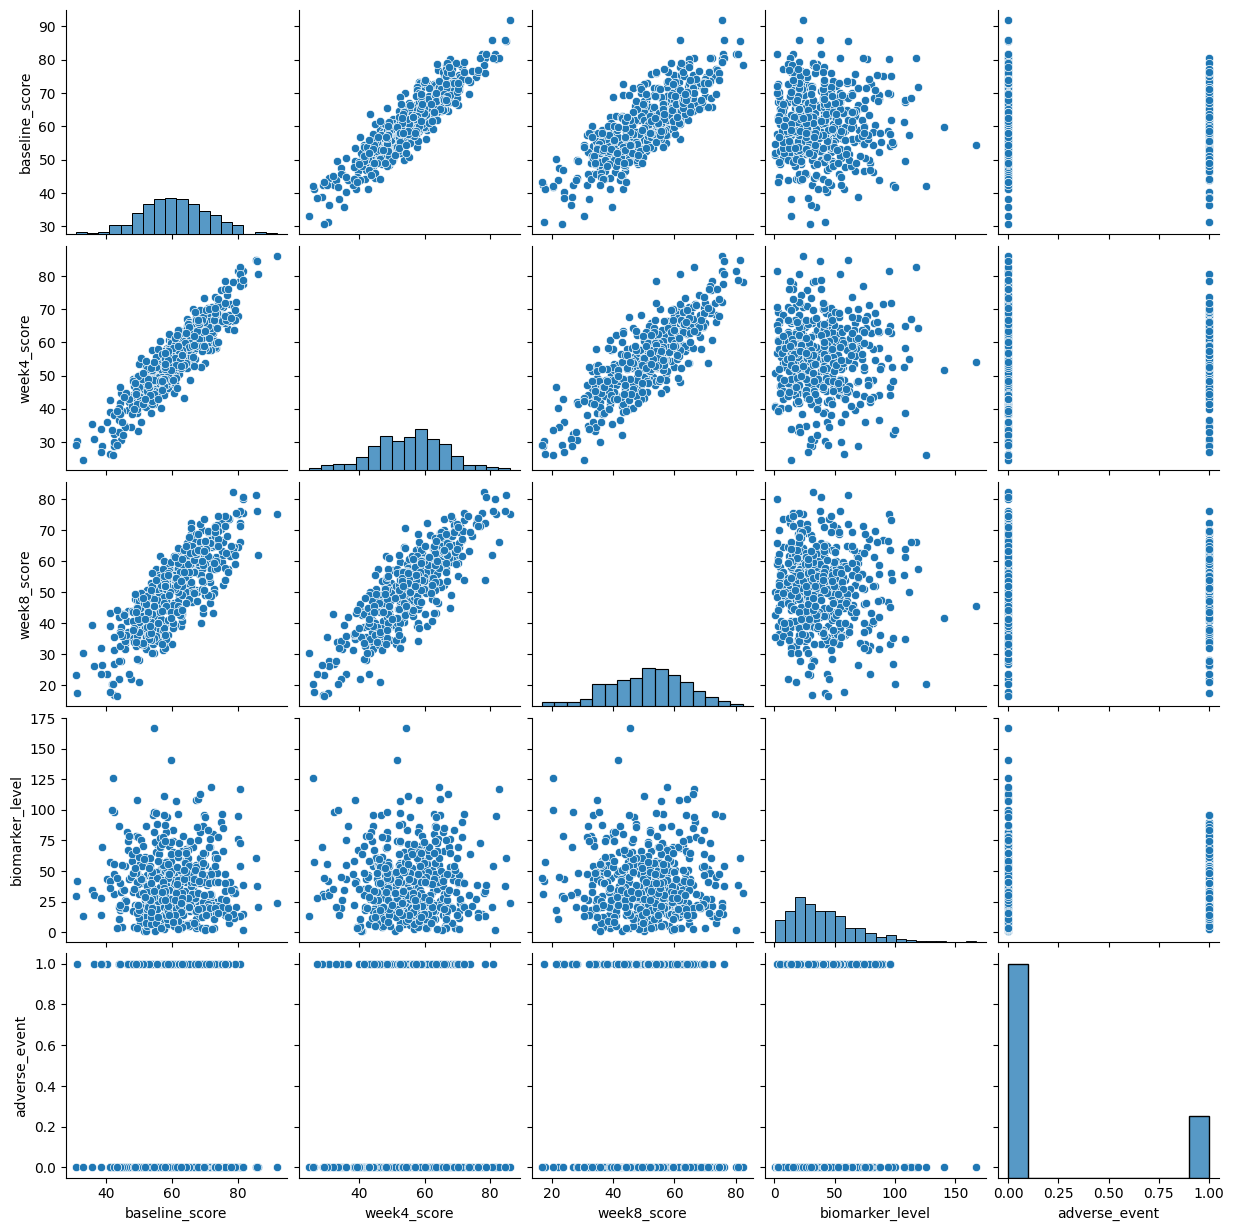

In [43]:
sns.pairplot(df[['treatment_group', 'baseline_score', 'week4_score', 'week8_score', 'biomarker_level','adverse_event']])

In [4]:

biomarker_level = df['biomarker_level'].dropna()

mean_value = biomarker_level.mean()
median_value = biomarker_level.median()

print("Mean:", round(mean_value, 2))
print("Median:", round(median_value, 2))

Mean: 39.66
Median: 34.5


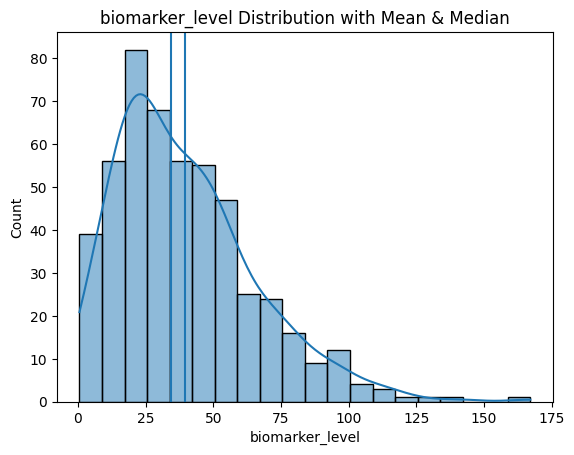

In [6]:
plt.figure()
sns.histplot(df['biomarker_level'], kde=True)
plt.axvline(mean_value)
plt.axvline(median_value)
plt.title("biomarker_level Distribution with Mean & Median")
plt.show()

In [7]:
biomarker_level.std()

25.843399004469376

In [8]:
# **IQR (Interquartile Range)**
Q1 = biomarker_level.quantile(0.25)
Q3 = biomarker_level.quantile(0.75)
IQR = Q3 - Q1

print("Q1:", round(Q1, 2))
print("Q3:", round(Q3, 2))
print("IQR:", round(IQR, 2))

Q1: 20.45
Q3: 54.2
IQR: 33.75


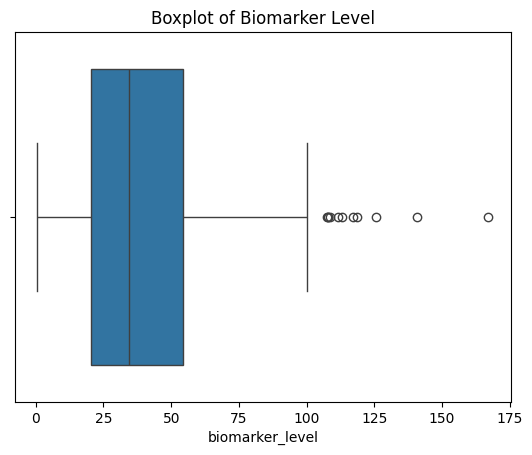

In [9]:
plt.figure()
sns.boxplot(x=biomarker_level)
plt.title("Boxplot of Biomarker Level")
plt.show()

In [10]:
skewness = biomarker_level.skew()
print("Skewness:", round(skewness, 2))

Skewness: 1.05


In [14]:
df.columns

Index(['patient_id', 'treatment_group', 'age', 'gender', 'dose',
       'baseline_score', 'week4_score', 'week8_score', 'biomarker_level',
       'adverse_event', 'improvement_score'],
      dtype='object')

In [13]:
df['improvement_score'] = df.baseline_score - df.week4_score
# apply all above to this feature

In [15]:
skewness = df['improvement_score'] .skew()
print("Skewness:", round(skewness, 2))

Skewness: 0.35


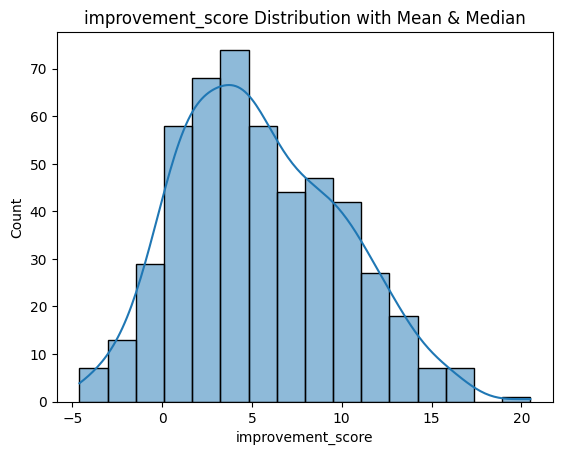

In [16]:
plt.figure()
sns.histplot(df['improvement_score'], kde=True)
plt.title("improvement_score Distribution with Mean & Median")
plt.show()

<Axes: xlabel='treatment_group', ylabel='improvement_score'>

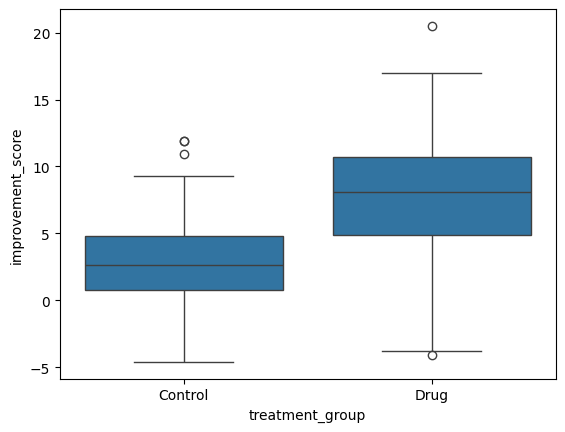

In [18]:
# does drug work?
sns.boxplot(x='treatment_group', y='improvement_score', data=df)

In [20]:
# mean value for improvement score for each group
df.groupby('treatment_group')['improvement_score'].mean().reset_index()

,treatment_group,improvement_score
0,Control,2.894672
1,Drug,7.943750


<Axes: xlabel='treatment_group', ylabel='improvement_score'>

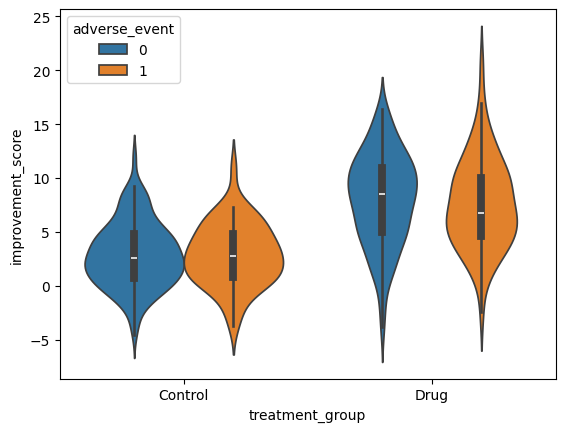

In [23]:

sns.violinplot(x='treatment_group', y='improvement_score',hue='adverse_event', data=df)

<Axes: xlabel='treatment_group', ylabel='count'>

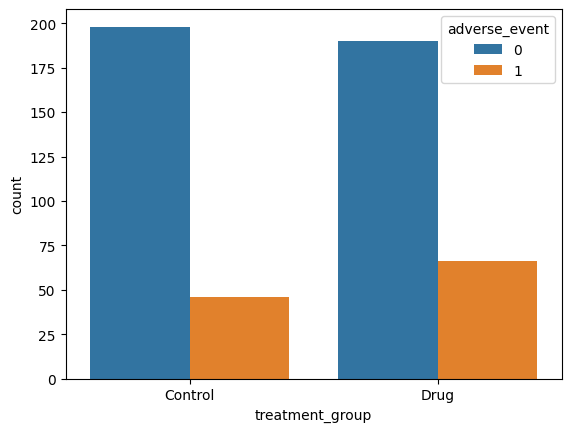

In [22]:
# is treatment associated with higher adverse events?
sns.countplot(x='treatment_group', hue='adverse_event', data=df)

In [24]:
pd.crosstab(df['treatment_group'], df['adverse_event'], normalize='index')

adverse_event,0,1
treatment_group,,
Control,0.811475,0.188525
Drug,0.742188,0.257812


<Axes: xlabel='dose', ylabel='improvement_score'>

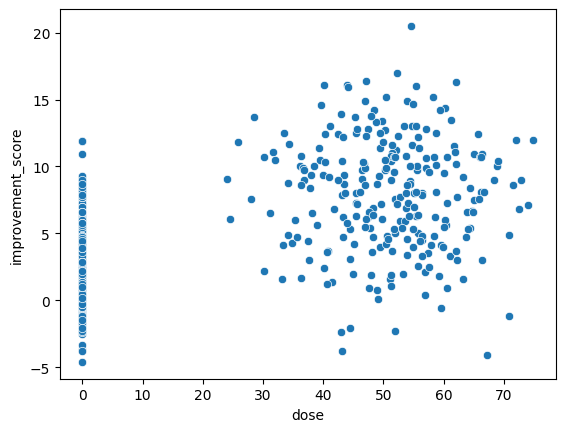

In [26]:
#Scatterplot
sns.scatterplot(x='dose', y='improvement_score', data=df)

<Axes: xlabel='dose', ylabel='improvement_score'>

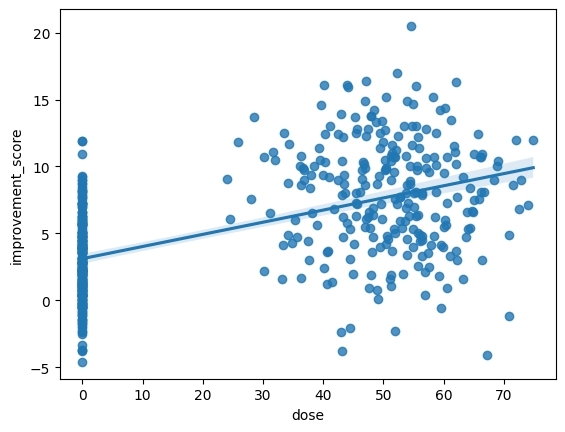

In [28]:
sns.regplot(x='dose', y='improvement_score', data=df)

<Axes: >

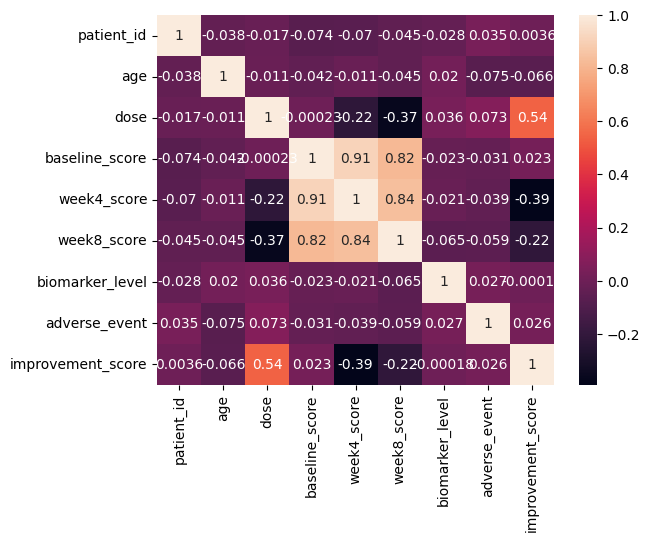

In [33]:
corr= df.corr(numeric_only=True)
sns.heatmap(corr,annot=True)